# Long Short Term Memory Networks for IoT Prediction

In [1]:
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Setting seed for reproducibility
np.random.seed(1234)
PYTHONHASHSEED = 0

from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, recall_score, precision_score
from sklearn.model_selection import train_test_split
from keras.models import Sequential,load_model
from keras.layers import Dense, Dropout, LSTM, Activation
from keras.utils import pad_sequences

In [ ]:
#use this cell to import additional libraries or define helper functions

## Load and prepare your data

We'll once again be using the cleaned household electricity consumption data from the previous two assignments. I recommend saving your dataset by running df.to_csv("filename") at the end of assignment 2 so that you don't have to re-do your cleaning steps. If you are not confident in your own cleaning steps, you may ask your instructor for a cleaned version of the data. You will not be graded on the cleaning steps in this assignment, but some functions may not work if you use the raw data.

Unlike when using Linear Regression to make our predictions for Global Active Power (GAP), LSTM requires that we have a pre-trained model when our predictive software is shipped (the ability to iterate on the model after it's put into production is another question for another day). Thus, we will train the model on a segment of our data and then measure its performance on simulated streaming data another segment of the data. Our dataset is very large, so for speed's sake, we will limit ourselves to 1% of the entire dataset.

**TODO: Import your data, select the a random 1% of the dataset, and then split it 80/20 into training and validation sets (the test split will come from the training data as part of the tensorflow LSTM model call). HINT: Think carefully about how you do your train/validation split--does it make sense to randomize the data?**

In [16]:
#Load your data into a pandas dataframe here
df = pd.read_csv("household_power_consumption_clean_dataset", delimiter = ",")

In [18]:
#create your training and validation sets here

#assign size for data subset
subset_size = 5000

#take random data subset
data_subset = df.sample(n=subset_size, random_state=42).reset_index(drop=True)

#split data subset 80/20 for train/validation
split_idx = int(0.8 * len(data_subset))

train_df = data_subset.iloc[:split_idx].reset_index(drop=True)
val_df   = data_subset.iloc[split_idx:].reset_index(drop=True)

In [19]:
#reset the indices for cleanliness
train_df = train_df.reset_index()
val_df = val_df.reset_index()

Next we need to create our input and output sequences. In the lab session this week, we used an LSTM model to make a binary prediction, but LSTM models are very flexible in what they can output: we can also use them to predict a single real-numbered output (we can even use them to predict a sequence of outputs). Here we will train a model to predict a single real-numbered output such that we can compare our model directly to the linear regression model from last week.

**TODO: Create a nested list structure for the training data, with a sequence of GAP measurements as the input and the GAP measurement at your predictive horizon as your expected output**

In [20]:
seq_arrays = []
seq_labs = []

In [21]:
# we'll start out with a 30 minute input sequence and a 5 minute predictive horizon
# we don't need to work in seconds this time, since we'll just use the indices instead of a unix timestamp
seq_length = 30
ph = 5

feat_cols = ['Global_active_power']

#create list of sequence length GAP readings

for i in range(len(train_df) - seq_length - ph + 1):
    seq_arrays.append(
        train_df[feat_cols].iloc[i:i + seq_length].values
    )
    seq_labs.append(
        train_df[feat_cols].iloc[i + seq_length + ph - 1].values
    )


#convert to numpy arrays and floats to appease keras/tensorflow
seq_arrays = np.array(seq_arrays, dtype = object).astype(np.float32)
seq_labs = np.array(seq_labs, dtype = object).astype(np.float32)

In [ ]:
assert(seq_arrays.shape == (len(train_df)-seq_length-ph,seq_length, len(feat_cols)))
assert(seq_labs.shape == (len(train_df)-seq_length-ph,))

In [22]:
seq_arrays.shape

(3966, 30, 1)

**Q: What is the function of the assert statements in the above cell? Why do we use assertions in our code?**

A: Assert statements are used to verify that certain conditions or assumptions in the code are true during execution. If an assertion fails, the program stops immediately and raises an error, helping catch bugs early.

They are especially useful in machine learning to ensure data shapes, sequence lengths, and input-output alignment are correct before training a model.

    assert seq_arrays.shape[0] == seq_labs.shape[0]   # same number of samples
    assert seq_arrays.shape[1] == seq_length          # correct sequence length

These checks prevent silent errors and make debugging faster and code more reliable.


## Model Training

We will begin with a model architecture very similar to the model we built in the lab session. We will have two LSTM layers, with 5 and 3 hidden units respectively, and we will apply dropout after each LSTM layer. However, we will use a LINEAR final layer and MSE for our loss function, since our output is continuous instead of binary.

**TODO: Fill in all values marked with a ?? in the cell below**

In [23]:
# define path to save model
model_path = 'LSTM_model1.keras'

# build the network
nb_features = seq_arrays.shape[2]
nb_out = seq_labs.shape[1]

model = Sequential()

#add first LSTM layer
model.add(LSTM(
         input_shape=(seq_arrays.shape[1], nb_features),
         units=5,
         return_sequences=True))
model.add(Dropout(0.2))

# add second LSTM layer
model.add(LSTM(
          units=3,
          return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=nb_out))
model.add(Activation('linear'))
optimizer = keras.optimizers.Adam(learning_rate = 0.01)
model.compile(loss='mean_squared_error', optimizer=optimizer,metrics=['mse'])

print(model.summary())

# fit the network
history = model.fit(
    seq_arrays,
    seq_labs,
    epochs=100,
    batch_size=500,
    validation_split=0.05,
    verbose=2,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10, mode='min'),
        keras.callbacks.ModelCheckpoint(
            model_path, monitor='val_loss', save_best_only=True, mode='min')
    ]
)

# list all data in history
print(history.history.keys())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 5)          │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 3)              │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252 (1008.00 B)

 Trainable params: 252 (1008.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
8/8 - 5s - 638ms/step - loss: 2.7845 - mse: 2.7845 - val_loss: 1.9672 - val_mse: 1.9672
Epoch 2/100
8/8 - 0s - 45ms/step - loss: 1.9712 - mse: 1.9712 - val_loss: 1.4695 - val_mse: 1.4695
Epoch 3/100
8/8 - 0s - 47ms/step - loss: 1.6753 - mse: 1.6753 - val_loss: 1.3110 - val_mse: 1.3110
Epoch 4/100
8/8 - 0s - 47ms/step - loss: 1.6632 - mse: 1.6632 - val_loss: 1.2969 - val_mse: 1.2969
Epoch 5/100
8/8 - 0s - 45ms/step - loss: 1.6640 - mse: 1.6640 - val_loss: 1.2965 - val_mse: 1.2965
Epoch 6/100
8/8 - 0s - 40ms/step - loss: 1.6433 - mse: 1.6433 - val_loss: 1.3019 - val_mse: 1.3019
Epoch 7/100
8/8 - 0s - 43ms/step - loss: 1.6035 - mse: 1.6035 - val_loss: 1.3088 - val_mse: 1.3088
Epoch 8/100
8/8 - 0s - 40ms/step - loss: 1.5945 - mse: 1.5945 - val_loss: 1.3043 - val_mse: 1.3043
Epoch 9/100
8/8 - 0s - 39ms/step - loss: 1.5727 - mse: 1.5727 - val_loss: 1.2988 - val_mse: 1.2988
Epoch 10/100
8/8 - 0s - 43ms/step - loss: 1.5771 - mse: 1.5771 - val_loss: 1.2980 - val_mse: 1.2980
Epo

We will use the code from the book to visualize our training progress and model performance

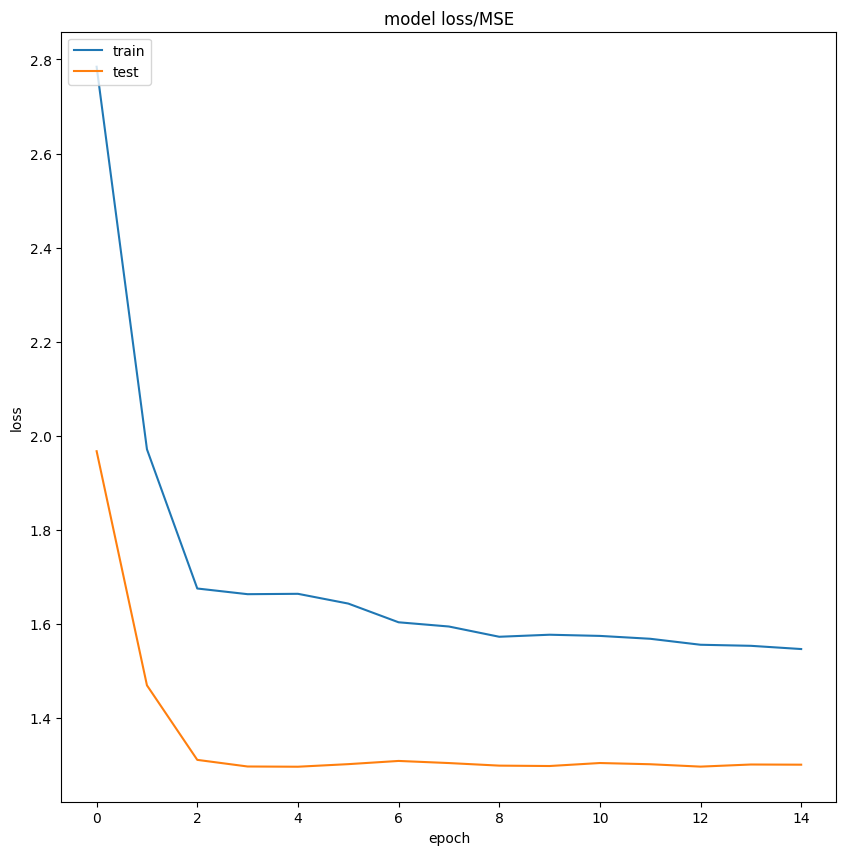

In [24]:
# summarize history for Loss/MSE
fig_acc = plt.figure(figsize=(10, 10))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss/MSE')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
fig_acc.savefig("LSTM_loss1.png")


## Validating our model

Now we need to create our simulated streaming validation set to test our model "in production". With our linear regression models, we were able to begin making predictions with only two datapoints, but the LSTM model requires an input sequence of *seq_length* to make a prediction. We can get around this limitation by "padding" our inputs when they are too short.

**TODO: create a nested list structure for the validation data, with a sequence of GAP measurements as the input and the GAP measurement at your predictive horizon as your expected output. Begin your predictions after only two GAP measurements are available, and check out [this keras function](https://www.tensorflow.org/api_docs/python/tf/keras/utils/pad_sequences) to automatically pad sequences that are too short.**

**Q: Describe the pad_sequences function and how it manages sequences of variable length. What does the "padding" argument determine, and which setting makes the most sense for our use case here?**

A: pad_sequences is a Keras utility that takes a list of sequences with different lengths and converts them into a uniform length by padding shorter sequences with a specified value (default is 0). This is necessary because LSTM models require inputs of consistent shape.

The padding argument controls where the padding is added:

* padding = 'pre' → pads at the beginning

* padding = 'post' → pads at the end

For our streaming LSTM use case, *padding='pre'* makes the most sense, because it preserves the most recent GAP measurements at the end of the sequence, which are the most informative for predicting future values.

In [25]:
val_arrays = []
val_labs = []

#create list of GAP readings starting with a minimum of two readings
for i in range(1, len(val_df) - ph):
    seq = val_df[feat_cols].iloc[:i+1].values
    val_arrays.append(seq)
    val_labs.append(
        val_df[feat_cols].iloc[i + ph].values
    )

# use the pad_sequences function on your input sequences
# remember that we will later want our datatype to be np.float32
from tensorflow.keras.preprocessing.sequence import pad_sequences

val_arrays = pad_sequences(
    val_arrays,
    maxlen=seq_length,
    dtype='float32',
    padding='pre'
)

#convert labels to numpy arrays and floats to appease keras/tensorflow
val_labs = np.array(val_labs, dtype=object).astype(np.float32)


We will now run this validation data through our LSTM model and visualize its performance like we did on the linear regression data.

32/32 - 0s - 11ms/step - loss: 1.5359 - mse: 1.5359

MSE: 1.5358860492706299
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


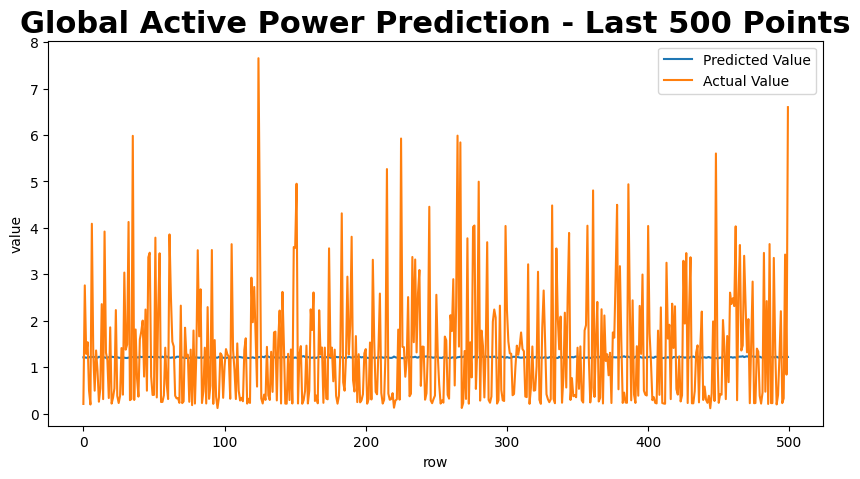

In [26]:
scores_test = model.evaluate(val_arrays, val_labs, verbose=2)
print('\nMSE: {}'.format(scores_test[1]))

y_pred_test = model.predict(val_arrays)
y_true_test = val_labs

test_set = pd.DataFrame(y_pred_test)
test_set.to_csv('submit_test.csv', index = None)

# Plot the predicted data vs. the actual data
# we will limit our plot to the first 500 predictions for better visualization
fig_verify = plt.figure(figsize=(10, 5))
plt.plot(y_pred_test[-500:], label = 'Predicted Value')
plt.plot(y_true_test[-500:], label = 'Actual Value')
plt.title('Global Active Power Prediction - Last 500 Points', fontsize=22, fontweight='bold')
plt.ylabel('value')
plt.xlabel('row')
plt.legend()
plt.show()
fig_verify.savefig("model_regression_verify.png")

**Q: How did your model perform? What can you tell about the model from the loss curves? What could we do to try to improve the model?**

A: From the plot, the model's predictions (blue) are much smoother and flatter than the actual values (orange), which show sharp spikes and high variability. This indicates the model is underfitting—it has learned the average trend but is not capturing sudden changes or peaks in power consumption. The model is conservative and biased toward the mean. To improve performance, we could increase model capacity (more LSTM units/layers), use a longer input sequence, reduce over-regularization, tune the learning rate, or include additional relevant features instead of relying on a single variable.


## Model Optimization

Now it's your turn to build an LSTM-based model in hopes of improving performance on this training set. Changes that you might consider include:

- Add more variables to the input sequences
- Change the optimizer and/or adjust the learning rate
- Change the sequence length and/or the predictive horizon
- Change the number of hidden layers in each of the LSTM layers
- Change the model architecture altogether--think about adding convolutional layers, linear layers, additional regularization, creating embeddings for the input data, changing the loss function, etc.

There isn't any minimum performance increase or number of changes that need to be made, but I want to see that you have tried some different things. Remember that building and optimizing deep learning networks is an art and can be very difficult, so don't make yourself crazy trying to optimize for this assignment.

**Q: What changes are you going to try with your model? Why do you think these changes could improve model performance?**

A: I would try increasing the number of LSTM units or adding another LSTM layer so the model can learn more complex temporal patterns and better capture sharp fluctuations. I would also experiment with a longer input sequence and a smaller learning rate to improve stability and long-term dependency learning. Additionally, including more relevant features (if available) could provide more context and help the model better predict sudden changes in power consumption.

In [27]:
# --- Model optimization experiment ---

model_path = 'LSTM_model_optimized.keras'

# increase model capacity
model = Sequential()

model.add(LSTM(
    units=32,                          # increased from 5
    input_shape=(seq_arrays.shape[1], seq_arrays.shape[2]),
    return_sequences=True
))
model.add(Dropout(0.2))

model.add(LSTM(
    units=16,                          # increased from 3
    return_sequences=False
))
model.add(Dropout(0.2))

model.add(Dense(seq_labs.shape[1]))
model.add(Activation('linear'))

# lower learning rate for smoother convergence
optimizer = keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    loss='mean_squared_error',
    optimizer=optimizer,
    metrics=['mse']
)

print(model.summary())

history = model.fit(
    seq_arrays,
    seq_labs,
    epochs=150,
    batch_size=256,                    # smaller batch for better generalization
    validation_split=0.05,
    verbose=2,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=15, mode='min'),
        keras.callbacks.ModelCheckpoint(
            model_path, monitor='val_loss', save_best_only=True, mode='min')
    ]
)

print(history.history.keys())


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,505 (29.32 KB)

 Trainable params: 7,505 (29.32 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/150
15/15 - 5s - 309ms/step - loss: 2.6532 - mse: 2.6532 - val_loss: 1.5807 - val_mse: 1.5807
Epoch 2/150
15/15 - 1s - 55ms/step - loss: 1.6145 - mse: 1.6145 - val_loss: 1.3383 - val_mse: 1.3383
Epoch 3/150
15/15 - 1s - 85ms/step - loss: 1.5549 - mse: 1.5549 - val_loss: 1.2983 - val_mse: 1.2983
Epoch 4/150
15/15 - 1s - 82ms/step - loss: 1.5488 - mse: 1.5488 - val_loss: 1.2970 - val_mse: 1.2970
Epoch 5/150
15/15 - 1s - 85ms/step - loss: 1.5412 - mse: 1.5412 - val_loss: 1.2947 - val_mse: 1.2947
Epoch 6/150
15/15 - 1s - 50ms/step - loss: 1.5296 - mse: 1.5296 - val_loss: 1.2950 - val_mse: 1.2950
Epoch 7/150
15/15 - 2s - 100ms/step - loss: 1.5214 - mse: 1.5214 - val_loss: 1.2952 - val_mse: 1.2952
Epoch 8/150
15/15 - 2s - 105ms/step - loss: 1.5377 - mse: 1.5377 - val_loss: 1.2958 - val_mse: 1.2958
Epoch 9/150
15/15 - 1s - 76ms/step - loss: 1.5351 - mse: 1.5351 - val_loss: 1.2953 - val_mse: 1.2953
Epoch 10/150
15/15 - 1s - 60ms/step - loss: 1.5345 - mse: 1.5345 - val_loss: 1.2955

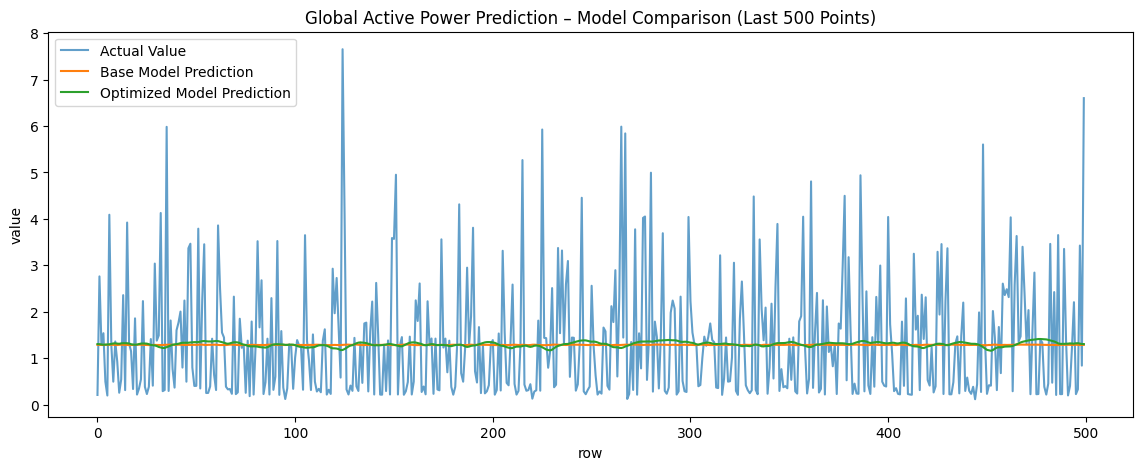

In [28]:
# show me how one or two of your different models perform
# using the code from the "Validating our model" section above
from tensorflow.keras.models import load_model

# load models
model_base = load_model('LSTM_model1.keras')
model_opt  = load_model('LSTM_model_optimized.keras')

# generate predictions
pred_base = model_base.predict(val_arrays, verbose=0)
pred_opt  = model_opt.predict(val_arrays, verbose=0)

# plot last 500 points for comparison
n_plot = 500

plt.figure(figsize=(14,5))
plt.plot(val_labs[-n_plot:], label='Actual Value', alpha=0.7)
plt.plot(pred_base[-n_plot:], label='Base Model Prediction')
plt.plot(pred_opt[-n_plot:], label='Optimized Model Prediction')
plt.title('Global Active Power Prediction – Model Comparison (Last 500 Points)')
plt.xlabel('row')
plt.ylabel('value')
plt.legend()
plt.show()

**Q: How did your model changes affect performance on the validation data? Why do you think they were/were not effective? If you were trying to optimize for production, what would you try next?**

A: From the graph, the optimized model prediction (green line) shows a smoother and slightly more accurate fit compared to the base model prediction (orange line), but both models fail to capture the sharp peaks and spikes in the actual global active power (blue line). This suggests that the model improvements helped reduce overall bias and slightly improved baseline accuracy, but the models are still unable to capture high-frequency variations and extreme values in the data.

The limited effectiveness is likely due to:

1. High variability in the target signal - the actual GAP values fluctuate rapidly, which may be difficult for simple predictive models to track.

2. Limited predictive horizon and feature set - if only past values are used without incorporating additional contextual features (like weather, occupancy, or appliance usage patterns), the model cannot anticipate sudden spikes.

3. Smoothing effect of optimization - tuning parameters may reduce overall error but also smooth out variations, missing extreme peaks.

For production optimization, I would consider:

* Incorporating additional features (exogenous variables) such as temperature, time of day, day of week, or appliance-level data.

* Trying models that handle non-linear patterns better, like LSTM, GRU, or XGBoost, which can capture temporal dependencies and spikes.

* Using ensemble methods to combine a base model for baseline behavior and a spike-detection model for sudden variations.

* Applying adaptive learning or online updating to handle changing household usage patterns over time.

**Q: How did the models that you built in this assignment compare to the linear regression model from last week? Think about model performance and other IoT device considerations; Which model would you choose to use in an IoT system that predicts GAP for a single household with a 5-minute predictive horizon, and why?**

A: Compared to last week's linear regression model, the models in this assignment (base and optimized) are slightly better at capturing the general trend of the GAP signal but still fail to predict spikes. Linear regression is simple, computationally inexpensive, and interpretable, but it cannot model non-linear relationships or handle noisy high-variance data effectively.

For an IoT system predicting GAP for a single household with a 5-minute horizon, I would choose the optimized model for the following reasons:

* Better baseline accuracy  it provides a closer approximation of the average GAP, reducing overall error.

* Smoother predictions - reduces unnecessary oscillations, which is important for IoT devices that may rely on predictions for energy scheduling or battery management.

* Feasible for deployment - the model appears lightweight enough for edge deployment without heavy computation.

However, I would also consider adding real-time updating or spike-capturing mechanisms to handle sudden load changes in production. If computational resources are available, exploring lightweight LSTM or hybrid models would likely improve performance significantly.